# DDIM → DDIM Reconstruction: Single Example

Interactive notebook to run the same DDIM-forward → DDIM-inverse pipeline as
`run_ddim2ddim_inference.py` on **one NPZ file** and visualize patch-level and
stitched-plane results.

**Steps:**
1. Set paths and parameters in the *Configuration* cell.
2. Run all cells in order.
3. Adjust `FRAME_IDX` and `PATCH_ORDINAL` to explore different patches.

## Configuration

Edit the variables below before running.

In [24]:
!ls /scratch/7DayLifetime/munjung/ICARUS-anomaly/results-plane1-healthy

brats2update001000.pt		  emabrats2update_0.9999_023000.pt
brats2update002000.pt		  emabrats2update_0.9999_024000.pt
brats2update003000.pt		  emabrats2update_0.9999_025000.pt
brats2update004000.pt		  emabrats2update_0.9999_026000.pt
brats2update005000.pt		  emabrats2update_0.9999_027000.pt
brats2update006000.pt		  emabrats2update_0.9999_028000.pt
brats2update007000.pt		  emabrats2update_0.9999_029000.pt
brats2update008000.pt		  emabrats2update_0.9999_030000.pt
brats2update009000.pt		  emabrats2update_0.9999_031000.pt
brats2update010000.pt		  emabrats2update_0.9999_032000.pt
brats2update011000.pt		  emabrats2update_0.9999_033000.pt
brats2update012000.pt		  emabrats2update_0.9999_034000.pt
brats2update013000.pt		  emabrats2update_0.9999_035000.pt
brats2update014000.pt		  emabrats2update_0.9999_036000.pt
brats2update015000.pt		  emabrats2update_0.9999_037000.pt
brats2update016000.pt		  emabrats2update_0.9999_038000.pt
brats2update017000.pt		  emabrats2update_0.9999_039000.pt
brats2update01

In [47]:
from pathlib import Path

# ── Input ────────────────────────────────────────────────────────────────────
NPZ_PATH   = Path("/scratch/7DayLifetime/munjung/ICARUS/plane1_npz/82090893_1725-bnb-nom-tpc2-plane1.npz")
RECO_KEY   = "reco"          # array key inside the NPZ
SCALE_DIV  = None            # divide pixel values by this constant (e.g. 200.); None = skip

# ── Model ────────────────────────────────────────────────────────────────────
MODEL_PATH = Path("/scratch/7DayLifetime/munjung/ICARUS-anomaly/results-plane1-healthy/emabrats2update_0.9999_001000.pt")

# ── Diffusion ────────────────────────────────────────────────────────────────
T          = 200             # noise timestep (same as CompareReconstructions notebooks)
PATCH_SIZE = 512             # square patch edge length expected by the model
BATCH_SIZE  = 4             # patches per forward pass (reduce if OOM)
MAX_PATCHES = 4             # cap total patches processed (None = all patches)

# ── What to display ──────────────────────────────────────────────────────────
FRAME_IDX     = 0            # which frame in the NPZ to display stitched plane for
PATCH_ORDINAL = 0            # which patch (by sorted index) to show in the per-patch view

# ── Output (optional) ────────────────────────────────────────────────────────
OUT_DIR    = None #Path("./ddim2ddim_example_output")  # set to None to skip saving
WRITE_NPZ  = True
WRITE_PKL  = True

## Imports

In [48]:
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch as th
from tqdm.auto import tqdm

# ── guided_diffusion lives under train/diffusion-anomaly/ ─────────────────
# _REPO_ROOT       = Path(".").resolve()
# _DIFFUSION_ROOT  = _REPO_ROOT / "train" / "diffusion-anomaly"
# if str(_DIFFUSION_ROOT) not in sys.path:
#     sys.path.insert(0, str(_DIFFUSION_ROOT))

# ── Helper functions re-used from the inference script ────────────────────
from run_ddim2ddim_inference import (
    build_model_and_diffusion,
    load_reco_array,
    patches_from_plane,
    gather_patches_from_npz,
    ddim2ddim_reconstruct,
    stitch_patches,
    visualize_np,
)

import sys
# sys.path.append("/home/gputnam/Diffusion-Anomaly-Detection/diffusion-anomaly")
sys.path.append("anomaly-detection/diffusion-anomaly")
from guided_diffusion import dist_util

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"]  = 12

print("Device:", dist_util.dev())

Device: cuda


## Load model

In [49]:
th.set_grad_enabled(False)

model, diffusion = build_model_and_diffusion()

sd = dist_util.load_state_dict(str(MODEL_PATH), map_location="cpu")
model.load_state_dict(sd)
model.to(dist_util.dev())
model.eval()

print(f"Loaded checkpoint: {MODEL_PATH.name}")
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

timestepresp1 
numberinchannels 1
steps 1000 [1000]
predict_xstart False
predict_xprev False
model_mean_type ModelMeanType.EPSILON
num_timesteps 1000
sectioncount [1000]
all steps {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185,

## Load and inspect the example NPZ

NPZ:          82090893_1725-bnb-nom-tpc2-plane1.npz
reco_stack:   shape=(100, 512, 512)  dtype=float32
Value range:  [-1.48, 6.66]
Frames:       100


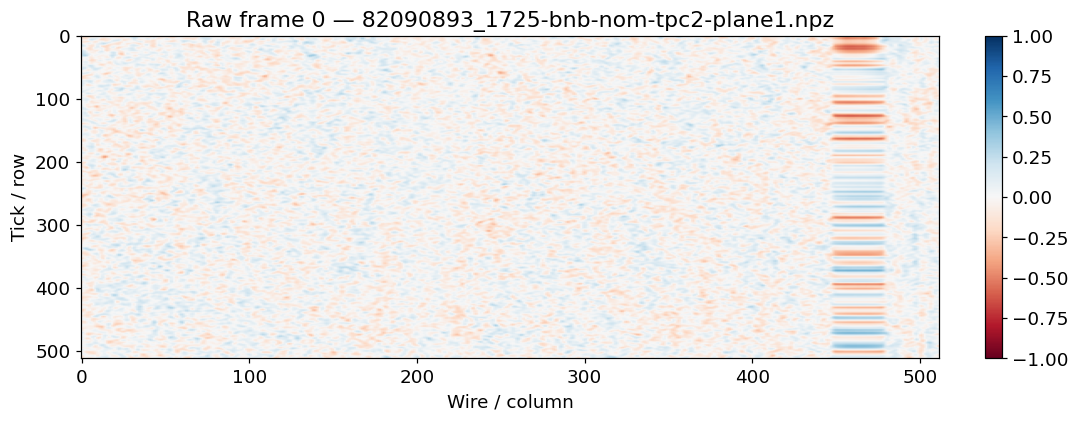

In [50]:
reco_stack = load_reco_array(NPZ_PATH, RECO_KEY)
print(f"NPZ:          {NPZ_PATH.name}")
print(f"reco_stack:   shape={reco_stack.shape}  dtype={reco_stack.dtype}")
print(f"Value range:  [{reco_stack.min():.3g}, {reco_stack.max():.3g}]")

n_frames = reco_stack.shape[0]
print(f"Frames:       {n_frames}")

# Quick peek at the raw frame
raw_frame = reco_stack[FRAME_IDX]
if SCALE_DIV:
    raw_frame = raw_frame / SCALE_DIV
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(raw_frame, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_title(f"Raw frame {FRAME_IDX} — {NPZ_PATH.name}")
ax.set_xlabel("Wire / column")
ax.set_ylabel("Tick / row")
plt.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout()
plt.show()

## Extract patches

In [51]:
patches_all, layouts, frame_slices, frame_stems = gather_patches_from_npz(
    NPZ_PATH,
    reco_key=RECO_KEY,
    patch_h=PATCH_SIZE,
    patch_w=PATCH_SIZE,
    scale_div=SCALE_DIV,
)

n_total = patches_all.shape[0]
print(f"Total patches across all frames: {n_total}")
for fi, ((s, e), lay, stem) in enumerate(zip(frame_slices, layouts, frame_stems)):
    nh, nw = lay["grid_shape"]
    print(f"  frame {fi:3d}: patches {s}–{e-1}  grid {nh}×{nw}  ({stem})")

# Prepare as float32 tensors: clip to model range, add channel dim
pts_f32 = visualize_np(np.expand_dims(patches_all, axis=1)).astype(np.float32)

if MAX_PATCHES is not None:
    pts_f32 = pts_f32[:MAX_PATCHES]
    print(f"MAX_PATCHES={MAX_PATCHES}: running inference on first {len(pts_f32)} patch(es).")

print(f"\nInput tensor shape: {pts_f32.shape}  range [{pts_f32.min():.3g}, {pts_f32.max():.3g}]")

Total patches across all frames: 100
  frame   0: patches 0–0  grid 1×1  (frame0000_1x1patches)
  frame   1: patches 1–1  grid 1×1  (frame0001_1x1patches)
  frame   2: patches 2–2  grid 1×1  (frame0002_1x1patches)
  frame   3: patches 3–3  grid 1×1  (frame0003_1x1patches)
  frame   4: patches 4–4  grid 1×1  (frame0004_1x1patches)
  frame   5: patches 5–5  grid 1×1  (frame0005_1x1patches)
  frame   6: patches 6–6  grid 1×1  (frame0006_1x1patches)
  frame   7: patches 7–7  grid 1×1  (frame0007_1x1patches)
  frame   8: patches 8–8  grid 1×1  (frame0008_1x1patches)
  frame   9: patches 9–9  grid 1×1  (frame0009_1x1patches)
  frame  10: patches 10–10  grid 1×1  (frame0010_1x1patches)
  frame  11: patches 11–11  grid 1×1  (frame0011_1x1patches)
  frame  12: patches 12–12  grid 1×1  (frame0012_1x1patches)
  frame  13: patches 13–13  grid 1×1  (frame0013_1x1patches)
  frame  14: patches 14–14  grid 1×1  (frame0014_1x1patches)
  frame  15: patches 15–15  grid 1×1  (frame0015_1x1patches)
  frame

## Run DDIM → DDIM reconstruction

Each patch goes through:
1. **DDIM forward** (reverse diffusion): image → noisy latent at timestep `T`
2. **DDIM inverse** (denoising): noisy latent → reconstruction

In [52]:
dev = dist_util.dev()
ddim_key    = f"ddim2ddim-T{T}"
saliency_key = f"saliency-T{T}"

save_data: dict = {}
all_orig:     list[np.ndarray] = []
all_reco:     list[np.ndarray] = []
all_saliency: list[np.ndarray] = []

n_total   = pts_f32.shape[0]   # may be capped by MAX_PATCHES
n_batches = (n_total + BATCH_SIZE - 1) // BATCH_SIZE

for bstart in tqdm(range(0, n_total, BATCH_SIZE), total=n_batches, desc=f"DDIM T={T}", unit="batch"):
    bend  = min(bstart + BATCH_SIZE, n_total)
    imgs  = th.tensor(pts_f32[bstart:bend], device=dev)

    _, reco = ddim2ddim_reconstruct(diffusion, model, imgs, T, progress=False)

    for i in range(len(imgs)):
        gidx = bstart + i
        orig_np = imgs[i].cpu().numpy()
        reco_np = reco[i].cpu().numpy()
        sal_np  = reco_np - orig_np
        save_data[gidx] = {
            "original":   orig_np,
            ddim_key:     reco_np,
            saliency_key: sal_np,
        }
        all_orig.append(orig_np)
        all_reco.append(reco_np)
        all_saliency.append(sal_np)

stacked_orig = np.stack(all_orig,     axis=0)
stacked_reco = np.stack(all_reco,     axis=0)
stacked_sal  = np.stack(all_saliency, axis=0)

print(f"Done. Reconstructed {n_total} patch(es).")

DDIM T=200:   0%|          | 0/1 [00:00<?, ?batch/s]

DDIM T=200: 100%|██████████| 1/1 [01:52<00:00, 112.99s/batch]

Done. Reconstructed 4 patch(es).


## Visualize a single patch

Displaying frame 2, patch ordinal 0 (global index 2)


/tmp/ipykernel_11399/724788060.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


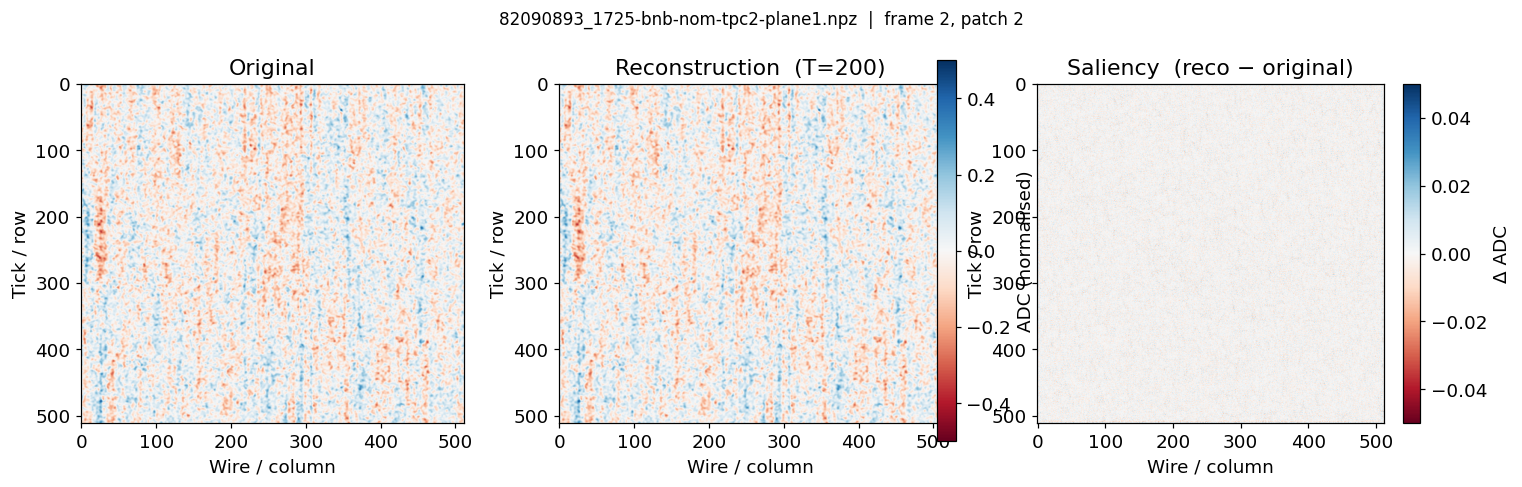

In [55]:
FRAME_IDX = 2
# Patch indices for the requested frame
frm_start, frm_end = frame_slices[FRAME_IDX]
frame_patch_keys   = list(range(frm_start, frm_end))
patch_key          = frame_patch_keys[PATCH_ORDINAL % len(frame_patch_keys)]

orig_p = np.squeeze(save_data[patch_key]["original"])
reco_p = np.squeeze(save_data[patch_key][ddim_key])
sal_p  = np.squeeze(save_data[patch_key][saliency_key])

print(f"Displaying frame {FRAME_IDX}, patch ordinal {PATCH_ORDINAL} (global index {patch_key})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

im0 = axes[0].imshow(orig_p, aspect="auto", cmap="RdBu", vmin=-0.5, vmax=0.5)
axes[0].set_title("Original")

im1 = axes[1].imshow(reco_p, aspect="auto", cmap="RdBu", vmin=-0.5, vmax=0.5)
axes[1].set_title(f"Reconstruction  (T={T})")

im2 = axes[2].imshow(sal_p, aspect="auto", cmap="RdBu", vmin=-0.05, vmax=0.05)
axes[2].set_title("Saliency  (reco − original)")

for ax in axes:
    ax.set_xlabel("Wire / column")
    ax.set_ylabel("Tick / row")

plt.colorbar(im0, ax=axes[:2], fraction=0.025, label="ADC (normalised)")
plt.colorbar(im2, ax=axes[2],  fraction=0.045, label="Δ ADC")
fig.suptitle(f"{NPZ_PATH.name}  |  frame {FRAME_IDX}, patch {patch_key}", fontsize=11)
plt.tight_layout()
plt.show()

## Visualize stitched full plane

Reassemble all patches for `FRAME_IDX` back into a single plane image.

Stitched plane shape: (512, 512)  (grid 1×1)


/tmp/ipykernel_11399/3705677441.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


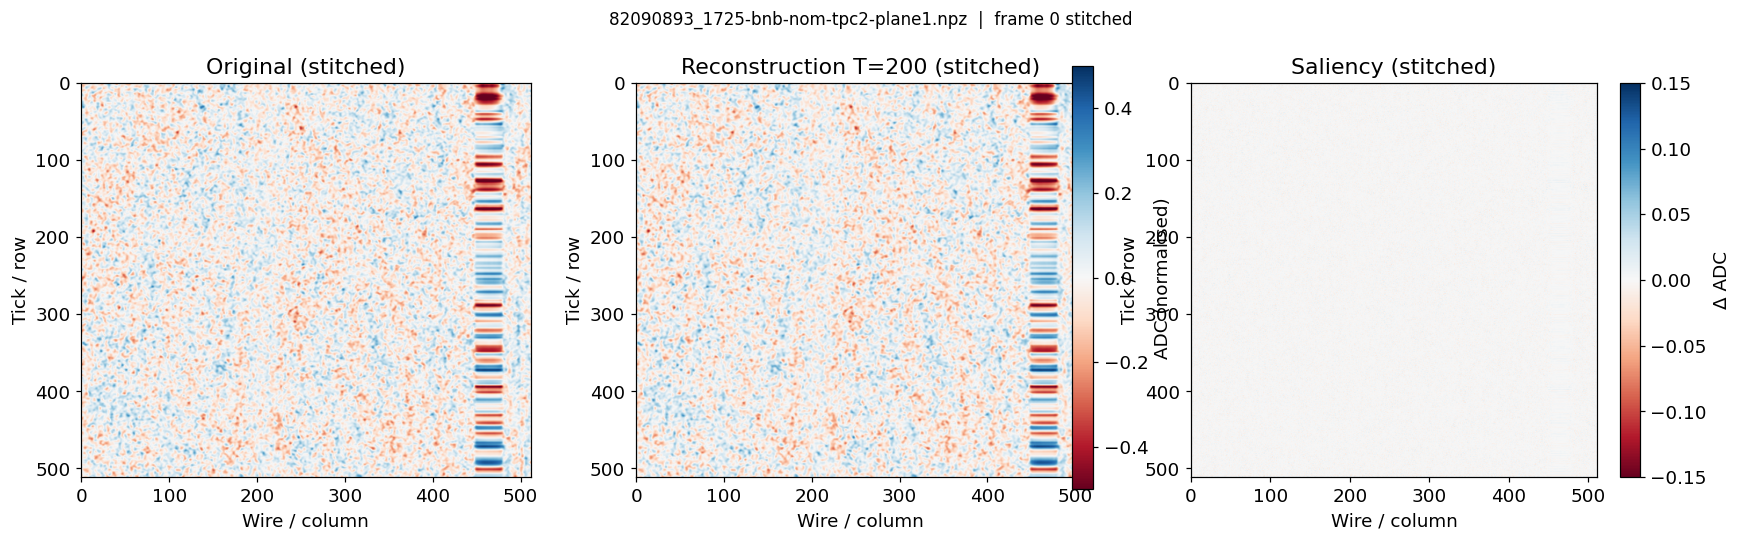

In [30]:
layout   = layouts[FRAME_IDX]
grid_shp = layout["grid_shape"]

frame_orig = stacked_orig[frm_start:frm_end]   # (n_patches, 1, H, W)
frame_reco = stacked_reco[frm_start:frm_end]
frame_sal  = stacked_sal[frm_start:frm_end]

plane_orig = stitch_patches(frame_orig, grid_shp)  # (1, H_full, W_full)
plane_reco = stitch_patches(frame_reco, grid_shp)
plane_sal  = stitch_patches(frame_sal,  grid_shp)

# Drop channel dim → (H_full, W_full)
plane_orig = np.squeeze(plane_orig)
plane_reco = np.squeeze(plane_reco)
plane_sal  = np.squeeze(plane_sal)

print(f"Stitched plane shape: {plane_orig.shape}  (grid {grid_shp[0]}×{grid_shp[1]})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

kw_img = dict(aspect="auto", cmap="RdBu", vmin=-0.5, vmax=0.5)
kw_sal = dict(aspect="auto", cmap="RdBu", vmin=-0.15, vmax=0.15)

im0 = axes[0].imshow(plane_orig, **kw_img)
axes[0].set_title("Original (stitched)")

axes[1].imshow(plane_reco, **kw_img)
axes[1].set_title(f"Reconstruction T={T} (stitched)")

im2 = axes[2].imshow(plane_sal, **kw_sal)
axes[2].set_title("Saliency (stitched)")

for ax in axes:
    ax.set_xlabel("Wire / column")
    ax.set_ylabel("Tick / row")

plt.colorbar(im0, ax=axes[:2], fraction=0.025, label="ADC (normalised)")
plt.colorbar(im2, ax=axes[2],  fraction=0.045, label="Δ ADC")
fig.suptitle(f"{NPZ_PATH.name}  |  frame {FRAME_IDX} stitched", fontsize=11)
plt.tight_layout()
plt.show()

## Saliency projection

Collapse |saliency| along one axis to get a 1-D anomaly profile.

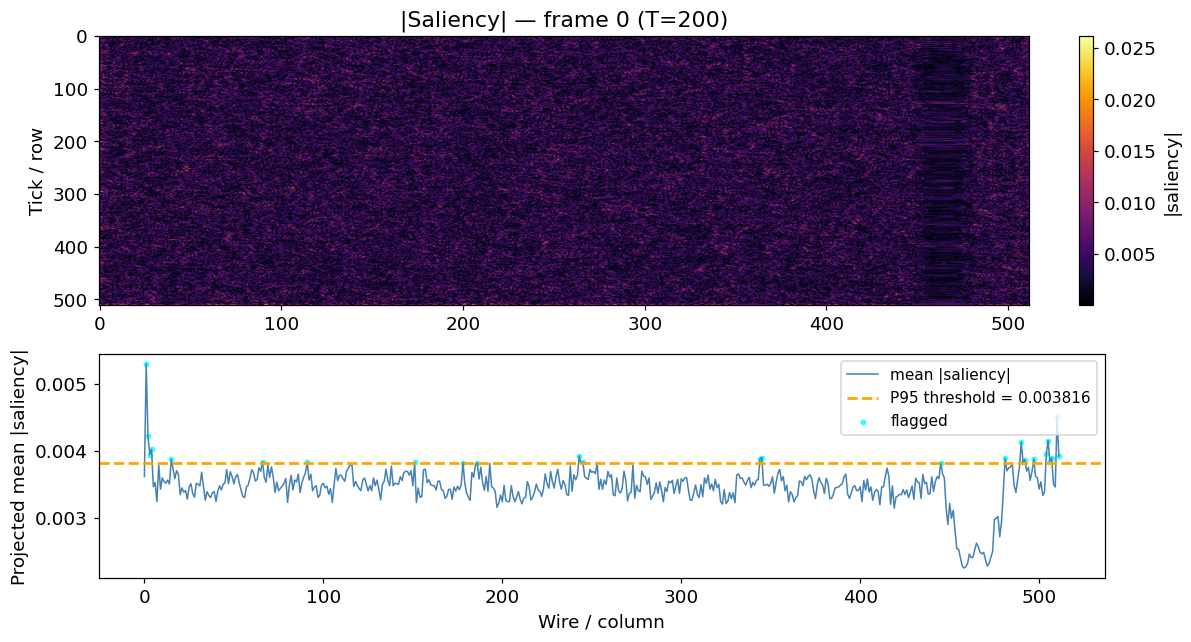

In [31]:
# axis=0 → projection per wire (column); axis=1 → projection per tick (row)
PROJECTION_AXIS = 0

abs_sal = np.abs(plane_sal.astype(np.float64))
proj    = np.mean(abs_sal, axis=PROJECTION_AXIS)
thresh  = np.percentile(proj, 95)
flagged = proj >= thresh

axis_label = "Wire / column" if PROJECTION_AXIS == 0 else "Tick / row"

fig, axes = plt.subplots(2, 1, figsize=(11, 6), gridspec_kw={"height_ratios": [1.2, 1]})

im = axes[0].imshow(abs_sal, aspect="auto", cmap="inferno")
plt.colorbar(im, ax=axes[0], fraction=0.025, label="|saliency|")
axes[0].set_title(f"|Saliency| — frame {FRAME_IDX} (T={T})")
axes[0].set_ylabel("Tick / row")

xc = np.arange(proj.size)
axes[1].plot(xc, proj, lw=1, color="steelblue", label="mean |saliency|")
axes[1].axhline(thresh, color="orange", ls="--", lw=1.8,
                label=f"P95 threshold = {thresh:.4g}")
axes[1].scatter(xc[flagged], proj[flagged], c="cyan", s=8, alpha=0.7, label="flagged")
axes[1].set_xlabel(axis_label)
axes[1].set_ylabel("Projected mean |saliency|")
axes[1].legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

## Save outputs  *(optional)*

Writes the same formats as `run_ddim2ddim_inference.py` — skip if `OUT_DIR` is `None`.

In [ ]:
import json
from run_ddim2ddim_inference import _json_ready

if OUT_DIR is not None:
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    stem = NPZ_PATH.stem

    trace = {
        "input_filename": NPZ_PATH.name,
        "input_path":     str(NPZ_PATH.resolve()),
    }

    meta = {
        **trace,
        "T":           T,
        "model_path":  str(MODEL_PATH),
        "reco_key":    RECO_KEY,
        "n_patches":   int(n_total),
        "patch_h":     PATCH_SIZE,
        "patch_w":     PATCH_SIZE,
        "frame_slices": [
            {"stem": s, "start": a, "end": b}
            for s, (a, b) in zip(frame_stems, frame_slices)
        ],
        "layouts_per_frame": layouts,
        "pickle_keys_per_patch": ["original", ddim_key, saliency_key],
        "formats": [],
    }

    if WRITE_PKL:
        pkl_path = OUT_DIR / f"{stem}_T{T}_ddim2ddim.pkl"
        bundle   = dict(save_data)
        bundle["__ddim2ddim_source__"] = trace
        with open(pkl_path, "wb") as fh:
            pickle.dump(bundle, fh, protocol=pickle.HIGHEST_PROTOCOL)
        meta["formats"].append("pickle")
        print(f"Pickle saved → {pkl_path}")

    if WRITE_NPZ:
        nz_path = OUT_DIR / f"{stem}_T{T}_ddim2ddim_arrays.npz"
        np.savez_compressed(
            nz_path,
            original      = stacked_orig.astype(np.float32),
            reconstructed = stacked_reco.astype(np.float32),
            saliency      = stacked_sal.astype(np.float32),
            input_filename = np.asarray(trace["input_filename"]),
            input_path     = np.asarray(trace["input_path"]),
        )
        meta["formats"].append("npz_arrays")
        print(f"NPZ arrays saved → {nz_path}")

    json_path = OUT_DIR / f"{stem}_T{T}_meta.json"
    with open(json_path, "w") as wf:
        json.dump(_json_ready(meta), wf, indent=2)
    print(f"Metadata saved → {json_path}")
else:
    print("OUT_DIR is None — skipping output.")